In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.integrate import solve_ivp

In [2]:
# Parameters
ro = 2500; cp = 100; hc = 15
h = 4; d = 0.01; w = 0.005
Tc = 318.16; Th = 356.16

In [3]:
# Model for face 1
def face1(ang, z):
    # Differential equation: face exposed to hot air
    dz1 = h * (Th - z) / (cp * d * ro * w)
    return dz1

In [4]:
# Model for face 2
def face2(ang, z):
    # Differential equation: face exposed to the coolant
    dz2 = -hc * (z - Tc) / (cp * d * ro * w)
    return dz2

In [5]:
# Integration times for face 1
t1 = (0, np.pi)
t1values = np.linspace(0, np.pi, 100)

# Integration times for face 2
t2 = (np.pi, 2 * np.pi)
t2values = np.linspace(np.pi, 2 * np.pi, 100)

# Cost function to be minimized
def int_tambor(condInicial):
    T1 = solve_ivp(face1, t1, condInicial, t_eval=t1values).y
    T2 = solve_ivp(face2, t2, y0=[T1[0, -1]], t_eval=t2values).y
    # Cost function
    return (condInicial - T2[0, -1])**2

In [6]:
# Optimization routine
result = minimize(int_tambor, x0=325)
print(result)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 4.727095638026278e-13
        x: [ 3.188e+02]
      nit: 4
      jac: [-1.349e-06]
 hess_inv: [[ 5.085e-01]]
     nfev: 10
     njev: 5


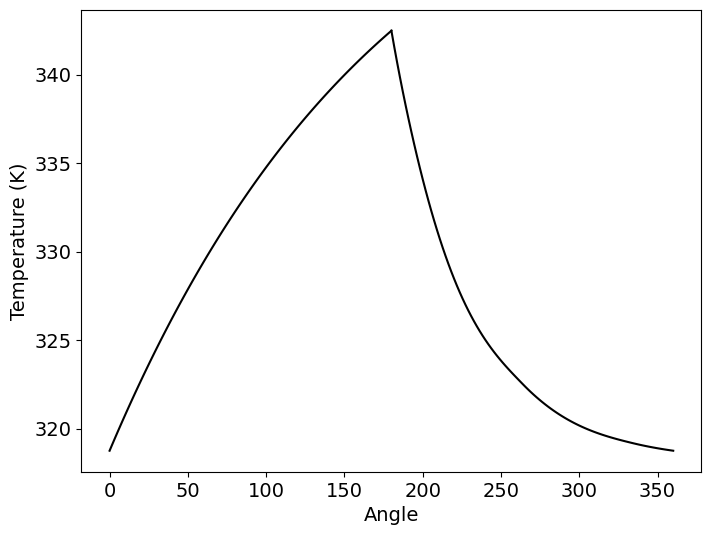

In [7]:
# Simulation to generate data for plotting
condInicial_optima = result.x
T1 = solve_ivp(face1, t1, condInicial_optima, t_eval=t1values).y
T2 = solve_ivp(face2, t2, y0=[T1[0, -1]], t_eval=t2values).y

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(t1values / np.pi * 180, T1[0], 'k')
plt.plot(t2values / np.pi * 180, T2[0], 'k')
plt.xlabel('Angle', fontsize=14)
plt.ylabel('Temperature (K)', fontsize=14)
plt.tick_params(axis='both', labelsize=14)